# Import Libraries

In [2]:
# =============================================
# MODEL BUILDING
# EcoType - Forest Cover Type Prediction
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Class imbalance handling
from imblearn.over_sampling import RandomOverSampler

import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print(" All libraries imported successfully!")

 All libraries imported successfully!


# Load Engineered Dataset

In [5]:
# Load the engineered dataset from Notebook 4

df = pd.read_csv('../data/forest_cover_engineered.csv')

print(f" Dataset loaded! Shape: {df.shape}")
df.head()

 Dataset loaded! Shape: (145890, 17)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Mean_Distance_To_Hydrology,Mean_Hillshade,Elevation_To_Roadway_Ratio,Hillshade_Diff
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,0,0,27,129.0,200.333333,5.080235,73.0
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,0,0,27,103.0,202.000000,6.624041,69.0
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,4,0,11,166.5,202.333333,0.881484,99.0
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,4,0,28,179.5,199.333333,0.901003,116.0
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,0,0,27,76.0,201.333333,6.619898,70.0


# Split Features and Target

In [8]:
# X = input features (everything except target)
# y = target column (what we want to predict)

X = df.drop(columns=['Cover_Type'])
y = df['Cover_Type']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTarget value counts (before balancing):")
print(y.value_counts())

Features (X) shape: (145890, 16)
Target (y) shape: (145890,)

Target value counts (before balancing):
Cover_Type
4    103071
6     31110
0      3069
3      2160
5      2160
2      2160
1      2160
Name: count, dtype: int64


# Handle Class Imbalance Using RandomOverSampler

In [11]:
# Remember — Lodgepole Pine had 70% of data!
# We balance all classes by oversampling minority classes

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)

print(f"Before balancing: {X.shape}")
print(f"After balancing:  {X_balanced.shape}")
print(f"\nTarget value counts (after balancing):")
print(pd.Series(y_balanced).value_counts())

Before balancing: (145890, 16)
After balancing:  (721497, 16)

Target value counts (after balancing):
Cover_Type
0    103071
4    103071
6    103071
3    103071
5    103071
2    103071
1    103071
Name: count, dtype: int64


# Train Test Split

In [14]:
# Split data into training set and testing set
# 80% for training, 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,       # 20% for testing
    random_state=42,     # for reproducibility
    stratify=y_balanced  # keeps class balance in both sets
)

print(f"Training set size:  {X_train.shape}")
print(f"Testing set size:   {X_test.shape}")

Training set size:  (577197, 16)
Testing set size:   (144300, 16)


# Define All 5 Models

In [17]:
# Define all 5 models we will train and compare

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42,
        n_jobs=-1  # use all CPU cores
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )
}

print(" All 5 models defined!")
print("Models to train:", list(models.keys()))

 All 5 models defined!
Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'XGBoost']


# Train and Evaluate All Models

In [20]:
# Train each model and record its accuracy
# This cell may take a few minutes — please be patient!

print("=== TRAINING ALL MODELS ===\n")
print("⏳ Please wait, this may take 3-5 minutes...\n")

results = {}  # store results here

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    
    print(f" {model_name} — Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

print("=== ALL MODELS TRAINED ===")

=== TRAINING ALL MODELS ===

⏳ Please wait, this may take 3-5 minutes...

Training Logistic Regression...
 Logistic Regression — Accuracy: 0.6150 (61.50%)

Training Decision Tree...
 Decision Tree — Accuracy: 0.9946 (99.46%)

Training Random Forest...
 Random Forest — Accuracy: 0.9963 (99.63%)

Training KNN...
 KNN — Accuracy: 0.9913 (99.13%)

Training XGBoost...
 XGBoost — Accuracy: 0.9805 (98.05%)

=== ALL MODELS TRAINED ===


# Compare Model Accuracies

=== MODEL COMPARISON ===
              Model  Accuracy
      Random Forest  0.996327
      Decision Tree  0.994567
                KNN  0.991337
            XGBoost  0.980527
Logistic Regression  0.615038


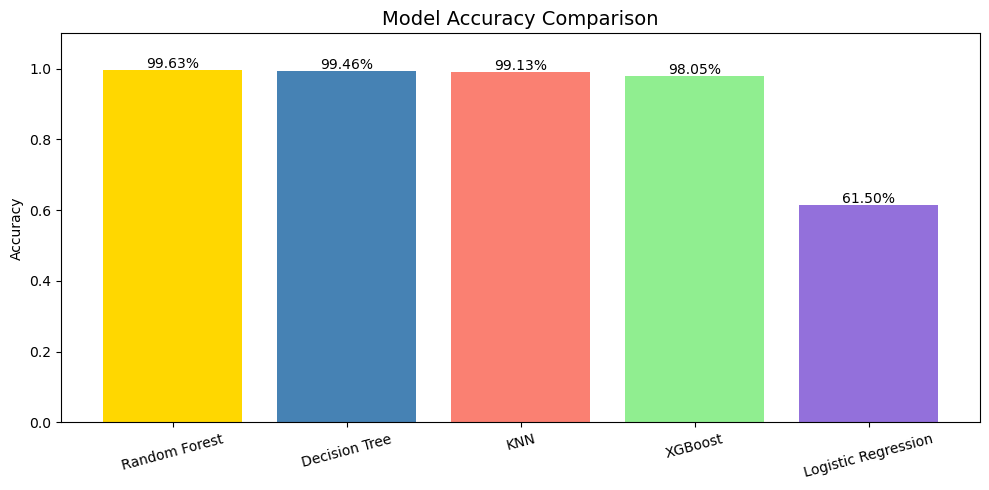

In [23]:
# Create a comparison bar chart of all model accuracies

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
}).sort_values('Accuracy', ascending=False)

print("=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], 
               results_df['Accuracy'], 
               color=['gold', 'steelblue', 'salmon', 
                      'lightgreen', 'mediumpurple'])

# Add accuracy labels on top of bars
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%',
             ha='center', fontsize=10)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Best Model Detailed Report

In [26]:
# Get the best model name
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f" Best Model: {best_model_name}")
print(f" Accuracy: {results[best_model_name]*100:.2f}%\n")

# Predict again with best model
y_pred_best = best_model.predict(X_test)

# Detailed classification report
print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred_best))

 Best Model: Random Forest
 Accuracy: 99.63%

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20614
           1       1.00      1.00      1.00     20614
           2       1.00      1.00      1.00     20614
           3       1.00      1.00      1.00     20615
           4       1.00      0.98      0.99     20614
           5       1.00      1.00      1.00     20614
           6       0.98      1.00      0.99     20615

    accuracy                           1.00    144300
   macro avg       1.00      1.00      1.00    144300
weighted avg       1.00      1.00      1.00    144300



# Confusion Matrix of Best Model

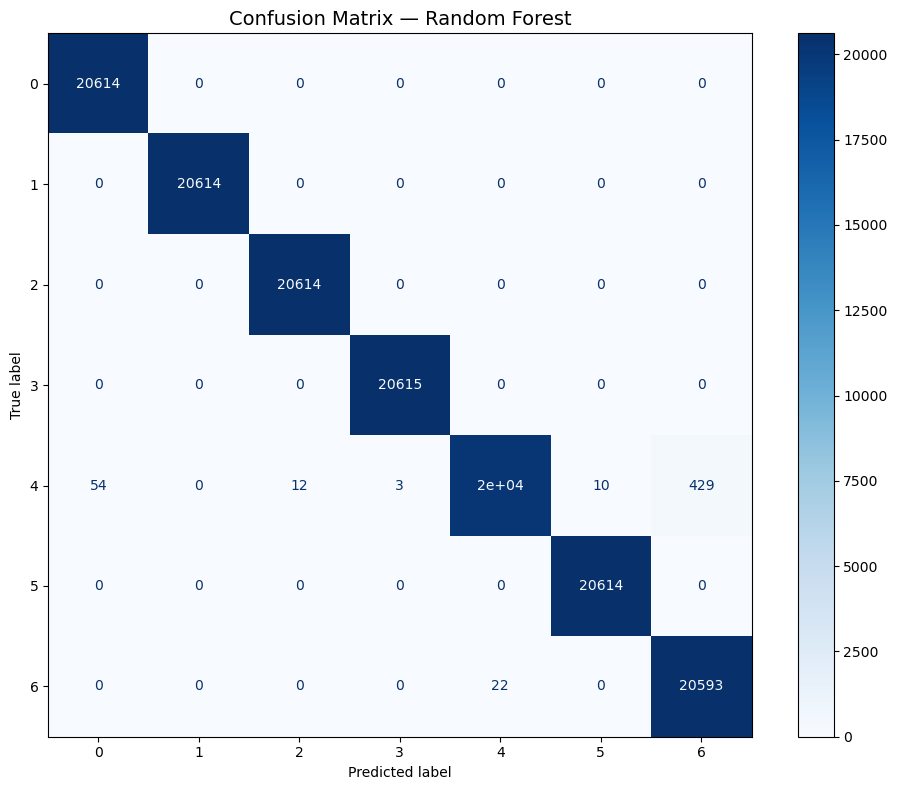

In [29]:
# Confusion matrix shows exactly where the model 
# gets confused between classes

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

#  Feature Importance (Random Forest)

=== FEATURE IMPORTANCE (Random Forest) ===
                           Feature  Importance
                         Elevation    0.211922
                         Soil_Type    0.146666
                   Wilderness_Area    0.101946
Horizontal_Distance_To_Fire_Points    0.091621
   Horizontal_Distance_To_Roadways    0.086166
        Elevation_To_Roadway_Ratio    0.080864
        Mean_Distance_To_Hydrology    0.046884
  Horizontal_Distance_To_Hydrology    0.036815
                     Hillshade_9am    0.031387
                            Aspect    0.030020
                    Hillshade_Diff    0.029217
    Vertical_Distance_To_Hydrology    0.028706
                    Hillshade_Noon    0.021755
                     Hillshade_3pm    0.019894
                    Mean_Hillshade    0.019705
                             Slope    0.016432


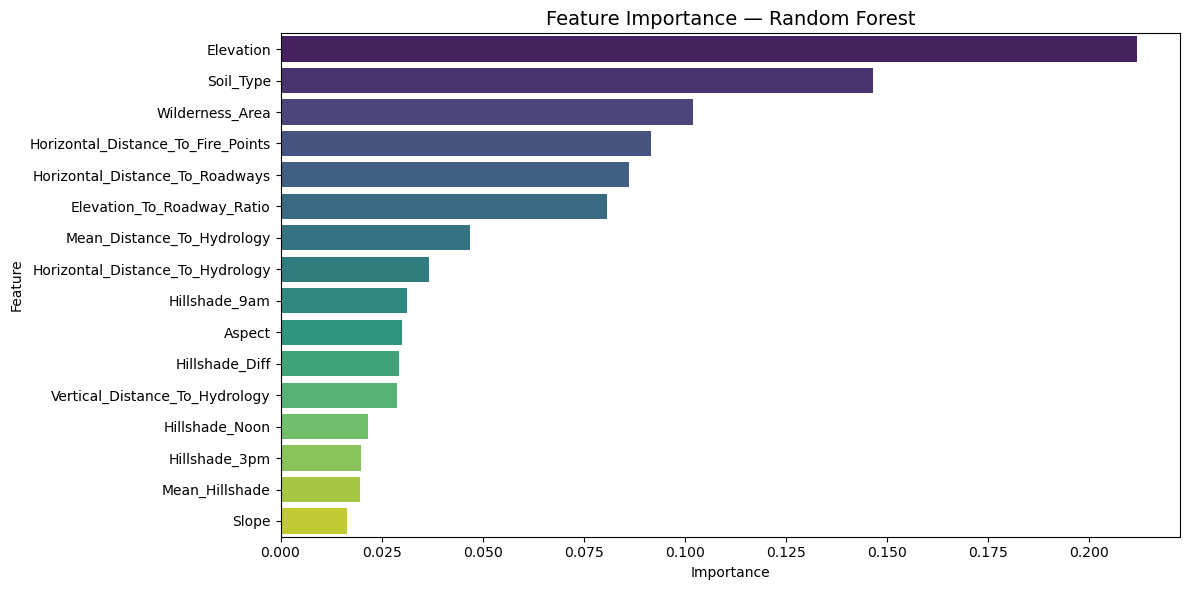

In [32]:
# Random Forest can tell us which features matter most
# This helps us understand what drives forest cover type

rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== FEATURE IMPORTANCE (Random Forest) ===")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

# Save All Trained Models

In [35]:
# Save all 5 trained models

for model_name, model in models.items():
    # Clean the name for filename
    filename = model_name.replace(' ', '_').lower()
    filepath = f'../models/{filename}.pkl'
    joblib.dump(model, filepath)
    print(f" Saved: {filepath}")

print("\n All models saved successfully!")

 Saved: ../models/logistic_regression.pkl
 Saved: ../models/decision_tree.pkl
 Saved: ../models/random_forest.pkl
 Saved: ../models/knn.pkl
 Saved: ../models/xgboost.pkl

 All models saved successfully!


## 📝 Summary from Notebook 5

- Loaded engineered dataset
- Split into X (features) and y (target)
- Handled class imbalance using RandomOverSampler
- Split data: 80% training, 20% testing
- Trained 5 models and compared:
    1. Random Forest      → 99.63%  (BEST)
    2. Decision Tree      → 99.46%
    3. KNN                → 99.13%
    4. XGBoost            → 98.05%
    5. Logistic Regression→ 61.50% (too simple for this data)
- Best model: Random Forest (99.63%)
- Logistic Regression is weak — data has non-linear patterns
- Feature importance confirms Elevation is the top predictor
- All 5 models saved as .pkl files
- Next step: Notebook 6 - Hyperparameter Tuning on Random Forest